# Practical Assignment-03: Performance Evaluation of Regression Model

## Aim
To develop a Linear Regression model for predicting median household income using housing-related features and evaluate its performance using appropriate metrics. Also, implement Gradient Descent optimization for Linear Regression.

## Application
Median Income Prediction using Linear Regression.



In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [24]:
data = pd.read_csv("california_housing.csv")

print("Dataset loaded successfully!")
print(data.head())

Dataset loaded successfully!
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


In [25]:
print("Rows and Columns:", data.shape)
print("\nColumn Names:")
print(data.columns)

Rows and Columns: (20640, 8)

Column Names:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')


In [26]:
print(data.isnull().sum())

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


In [27]:
X = data[["AveRooms"]]
y = data["MedInc"]

print("Input feature: AveRooms")
print("Target: MedInc")

print("Input features:")
print(X.columns)

print("\nTarget:")
print("MedInc")

Input feature: AveRooms
Target: MedInc
Input features:
Index(['AveRooms'], dtype='object')

Target:
MedInc


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16512, 1)
Testing data: (4128, 1)


In [29]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [30]:
y_pred = model.predict(X_test)

print("First 5 actual values:")
print(y_test.head().values)

print("\nFirst 5 predicted values:")
print(y_pred[:5])

First 5 actual values:
[1.6812 2.5313 3.4801 5.7376 3.725 ]

First 5 predicted values:
[3.54759458 3.77465765 3.48995772 4.07598131 3.896234  ]


In [31]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("-----------------")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

Model Performance
-----------------
MAE: 1.2512770639804451
MSE: 3.259728297673223
RMSE: 1.8054717659584774
R2 Score: 0.07897561134324105


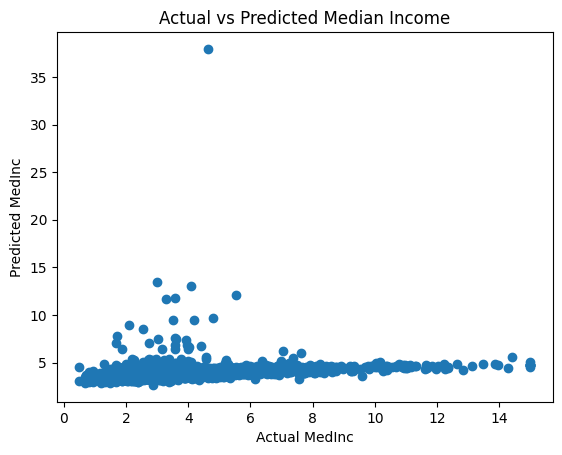

In [32]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual MedInc")
plt.ylabel("Predicted MedInc")

plt.title("Actual vs Predicted Median Income")

plt.show()

In [33]:
x = data["AveRooms"].values
y = data["MedInc"].values

print("Input: AveRooms")
print("Output: MedInc")

Input: AveRooms
Output: MedInc


In [34]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

Training samples: 16512
Testing samples: 4128


In [35]:
mean_x = np.mean(x_train)
std_x = np.std(x_train)

x_train = (x_train - mean_x) / std_x
x_test = (x_test - mean_x) / std_x

print("Input data scaled successfully!")

Input data scaled successfully!


In [36]:
m = 0
c = 0

learning_rate = 0.01
epochs = 1000

n = len(x_train)

cost_history = []

In [37]:
for i in range(epochs):

    y_pred = m * x_train + c

    error = y_pred - y_train

    dm = (2 / n) * np.sum(error * x_train)

    dc = (2 / n) * np.sum(error)

    m = m - learning_rate * dm

    c = c - learning_rate * dc

    cost = np.mean(error ** 2)

    cost_history.append(cost)

print("Gradient Descent completed!")
print("Final slope:", m)
print("Final intercept:", c)

Gradient Descent completed!
Final slope: 0.6398478764990742
Final intercept: 3.8807542509785065


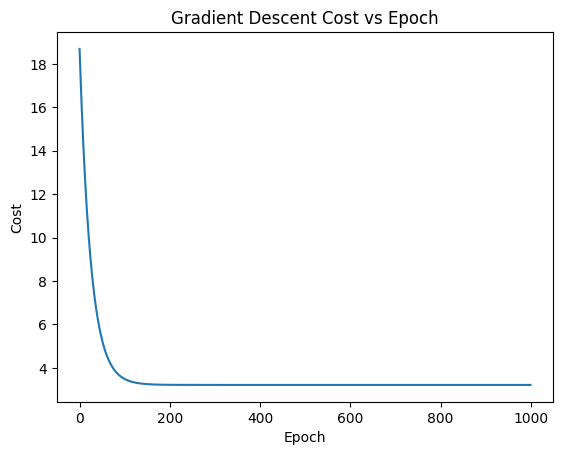

In [38]:
plt.plot(cost_history)

plt.xlabel("Epoch")
plt.ylabel("Cost")

plt.title("Gradient Descent Cost vs Epoch")

plt.show()

In [39]:
y_pred_gd = m * x_test + c

print("First 5 Gradient Descent predictions:")
print(y_pred_gd[:5])

First 5 Gradient Descent predictions:
[3.54759457 3.77465764 3.48995771 4.07598131 3.89623399]


In [40]:
mae_gd = mean_absolute_error(y_test, y_pred_gd)

mse_gd = mean_squared_error(y_test, y_pred_gd)

rmse_gd = np.sqrt(mse_gd)

r2_gd = r2_score(y_test, y_pred_gd)

print("Gradient Descent Performance")
print("----------------------------")
print("MAE:", mae_gd)
print("MSE:", mse_gd)
print("RMSE:", rmse_gd)
print("R2 Score:", r2_gd)

Gradient Descent Performance
----------------------------
MAE: 1.251277063157317
MSE: 3.259728296654361
RMSE: 1.805471765676318
R2 Score: 0.07897561163111677


In [41]:
print("Linear Regression Performance")
print("-----------------------------")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

print("\nGradient Descent Performance")
print("----------------------------")
print("MAE:", mae_gd)
print("MSE:", mse_gd)
print("RMSE:", rmse_gd)
print("R2 Score:", r2_gd)

Linear Regression Performance
-----------------------------
MAE: 1.2512770639804451
MSE: 3.259728297673223
RMSE: 1.8054717659584774
R2 Score: 0.07897561134324105

Gradient Descent Performance
----------------------------
MAE: 1.251277063157317
MSE: 3.259728296654361
RMSE: 1.805471765676318
R2 Score: 0.07897561163111677


## Conclusion

Linear Regression was successfully implemented to predict median household income using the California Housing dataset. The model was evaluated using MAE, MSE, RMSE and R² Score. Gradient Descent was also implemented for Linear Regression. The cost decreased with increasing epochs, showing that the model parameters were optimized successfully.
